In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer

# load test set
test_df = pd.read_csv('../data/processed/test.csv')
test_df['clean_text'] = test_df['clean_text'].fillna('').astype(str)
y_true = test_df['label'].values

# load baseline model and vectoriser
lr_model = joblib.load('../models/lr_model.pkl')
vectoriser = joblib.load('../models/tfidf_vectorizer.pkl')
X_test = vectoriser.transform(test_df['clean_text'])
y_baseline = lr_model.predict(X_test)

# load distilbert predictions
distilbert_df = pd.read_csv('../data/processed/distilbert_predictions.csv')
y_distilbert = distilbert_df['prediction'].values

print('data loaded')
print(f'test size: {len(y_true)}')

data loaded
test size: 23208


In [2]:
# build comparison table
def get_metrics(y_true, y_pred):
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'f1':        round(f1_score(y_true, y_pred, average='weighted'), 4)
    }

baseline_metrics   = get_metrics(y_true, y_baseline)
distilbert_metrics = get_metrics(y_true, y_distilbert)

comparison_df = pd.DataFrame({
    'TF-IDF + LR':  baseline_metrics,
    'DistilBERT':   distilbert_metrics
})

print(comparison_df)

# save to results folder
os.makedirs('../results', exist_ok=True)
comparison_df.to_csv('../results/model_comparison.csv')
print('\nsaved to results/model_comparison.csv')

           TF-IDF + LR  DistilBERT
accuracy        0.9413      0.9813
precision       0.9415      0.9813
recall          0.9413      0.9813
f1              0.9413      0.9813

saved to results/model_comparison.csv


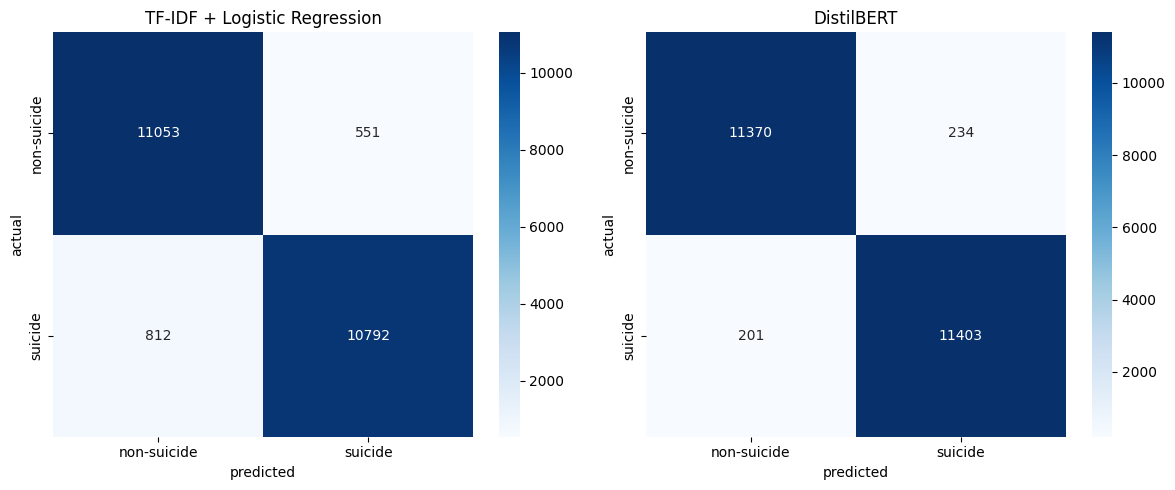

saved to results/confusion_matrix_comparison.png


In [ ]:
# plot both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_baseline, y_distilbert],
    ['TF-IDF + Logistic Regression', 'DistilBERT']
):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['non-suicide', 'suicide'],
                yticklabels=['non-suicide', 'suicide'])
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../results/confusion_matrices_comparison.png', dpi=150)
plt.show()
print('saved to results/confusion_matrices_comparison.png')

In [4]:
# sanity check: label order in distilbert_predictions.csv must match test.csv row-for-row
# if it doesn't, the two prediction arrays are misaligned and mcnemar will be wrong
assert np.array_equal(y_true, distilbert_df['label'].values), 'test label order mismatch between files'
print('label order check passed')
print(f'baseline accuracy:   {np.mean(y_baseline == y_true):.4f}')
print(f'distilbert accuracy: {np.mean(y_distilbert == y_true):.4f}')

label order check passed
baseline accuracy:   0.9413
distilbert accuracy: 0.9813


In [5]:
from scipy.stats import chi2

# boolean masks for correctness
baseline_correct = (y_baseline == y_true)
distil_correct = (y_distilbert == y_true)

# discordant pairs are what mcnemar uses
b = np.sum(baseline_correct & ~distil_correct)   # baseline right, distilbert wrong
c = np.sum(~baseline_correct & distil_correct)   # baseline wrong, distilbert right

print('baseline only correct:', b)
print('distilbert only correct:', c)

# mcnemar chi-squared with continuity correction
# formula: (|b - c| - 1)^2 / (b + c)
statistic = (abs(b - c) - 1) ** 2 / (b + c)
p_value = chi2.sf(statistic, df=1)

print('mcnemar statistic:', statistic)
print('p-value:', p_value)

baseline only correct: 186
distilbert only correct: 1114
mcnemar statistic: 661.0223076923077
p-value: 8.95379491680337e-146


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# get vocabulary and coefficients
feature_names = vectoriser.get_feature_names_out()
coefficients = lr_model.coef_[0]

# sort indices by coefficient value
sorted_idx = np.argsort(coefficients)

# top 20 features pushing toward suicide class (positive coef)
top_pos_idx = sorted_idx[-20:]
top_pos_names = feature_names[top_pos_idx]
top_pos_coefs = coefficients[top_pos_idx]

# top 20 features pushing toward non-suicide class (negative coef)
top_neg_idx = sorted_idx[:20]
top_neg_names = feature_names[top_neg_idx]
top_neg_coefs = coefficients[top_neg_idx]

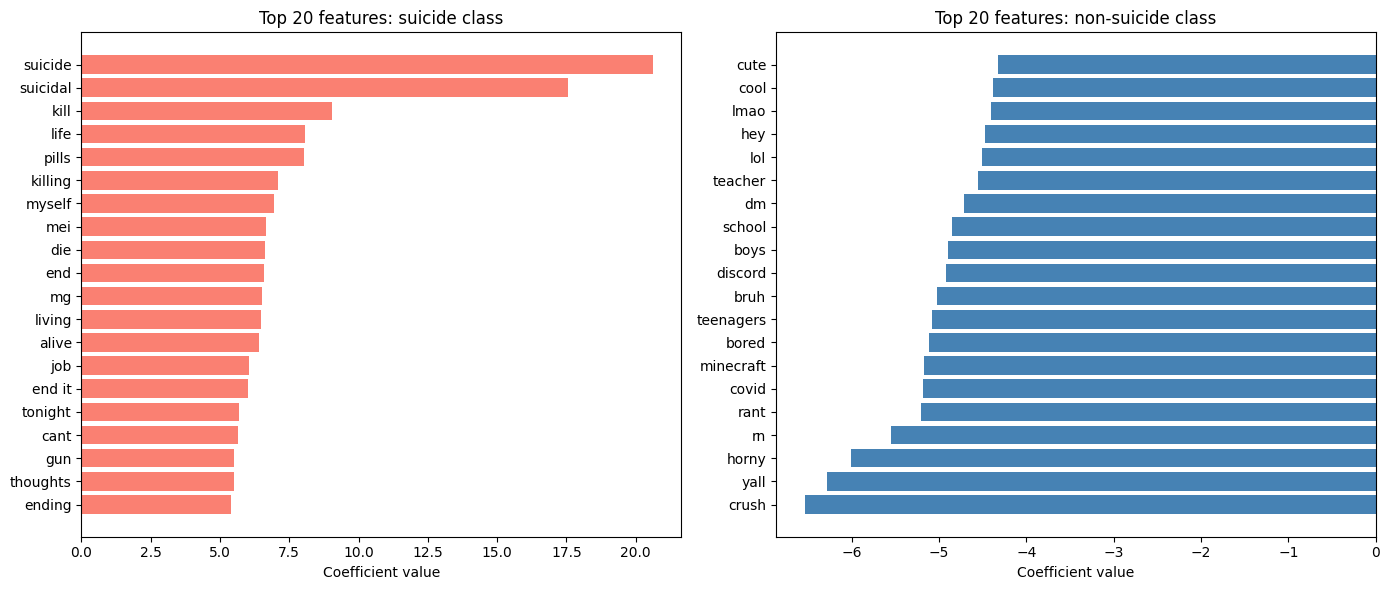

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# suicide-class features (positive coefficients)
axes[0].barh(range(20), top_pos_coefs, color='salmon')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_pos_names)
axes[0].set_title('Top 20 features: suicide class')
axes[0].set_xlabel('Coefficient value')

# non-suicide features (negative coefficients)
axes[1].barh(range(20), top_neg_coefs, color='steelblue')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_neg_names)
axes[1].set_title('Top 20 features: non-suicide class')
axes[1].set_xlabel('Coefficient value')

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
import random

random.seed(42)

# find indices where baseline was wrong (y_baseline computed in cell 0)
errors = []
for i in range(len(y_baseline)):
    if y_baseline[i] != y_true[i]:
        errors.append({
            'text': test_df['clean_text'].iloc[i],
            'true_label': y_true[i],
            'predicted': y_baseline[i]
        })

error_df = pd.DataFrame(errors)
print(f'Total baseline errors: {len(error_df)}')
print(error_df['true_label'].value_counts())

Total baseline errors: 1363
true_label
1    812
0    551
Name: count, dtype: int64


In [9]:
# split errors by type
false_negatives = error_df[
    (error_df['true_label'] == 1) &
    (error_df['predicted'] == 0)
]

false_positives = error_df[
    (error_df['true_label'] == 0) &
    (error_df['predicted'] == 1)
]

print(f"False negatives (missed suicide): {len(false_negatives)}")
print(f"False positives (wrong alarm): {len(false_positives)}")

# sample false negatives
print("\n--- FALSE NEGATIVES (true=suicide, predicted=non-suicide) ---")
for i, row in false_negatives.sample(min(10, len(false_negatives)), random_state=42).iterrows():
    print(f"\n[{i}] True: {row['true_label']} | Predicted: {row['predicted']}")
    print(row['text'][:300])
    print('---')

# sample false positives
print("\n--- FALSE POSITIVES (true=non-suicide, predicted=suicide) ---")
for i, row in false_positives.sample(min(10, len(false_positives)), random_state=42).iterrows():
    print(f"\n[{i}] True: {row['true_label']} | Predicted: {row['predicted']}")
    print(row['text'][:300])
    print('---')

False negatives (missed suicide): 812
False positives (wrong alarm): 551

--- FALSE NEGATIVES (true=suicide, predicted=non-suicide) ---

[433] True: 1 | Predicted: 0
modsfrequenters of this subreddit i need advicelet me start off by saying i am not suicidal i just need advice on dealing with the amount of inyourface coveridge of the shooting there has been lately its really starting to bum me out and i figure the people who frequent this subreddit and the mods m
---

[972] True: 1 | Predicted: 0
be honesti just recently started posting after a terrible string of bad luck drugs and just all around bad choices do reading others peoples struggle help you or make it worst i love all the encouraging stuff people say on this sub it actually makes me have a little faith for some of humanity tldr a
---

[401] True: 1 | Predicted: 0
helpdoes anyone else start sweating and shaking when seen or talk to any person
---

[506] True: 1 | Predicted: 0
i decided to attempt to tackle exactly why we shou